[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch01_workbook.ipynb)

# Predicting the next word

A language model gives every word that could come next a probability, given
the words before it. A count model takes those probabilities from how often
each word follows the same words in Pride and Prejudice.

In [1]:
#@title Setup: run this cell first
import os
import re
import urllib.request
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# Every chart is 6 by 3.5 inches, laid out so that no label is cut off.
plt.rcParams.update({"figure.figsize": (6, 3.5), "figure.autolayout": True, "axes.titlesize": 10})


# A typed text split into lowercase words, as the novel is split.
def words(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)*", str(text).lower().replace("’", "'"))


# The words counted in c, most frequent first; a tie goes to the word first in the alphabet.
def ranked(c, k=None):
    return sorted(c.items(), key=lambda wx: (-wx[1], wx[0]))[:k]


# The likeliest word in c, with its count, its probability and the words tied with it.
def likeliest(c):
    (w, x), total, ties = ranked(c, 1)[0], sum(c.values()), list(c.values()).count(max(c.values()))
    tie = f", tied with {ties - 1} other word(s) and first in the alphabet" if ties > 1 else ""
    return f"\"{w}\", {x:,} of {total:,} times (probability {x / total:.3f}){tie}"


# The context lengths TWO_WORDS asks for: [1], or [1, 2] when it is True. A value other
# than True or False stops with a sentence.
def orders(two_words):
    if type(two_words) is bool:
        return [1, 2] if two_words else [1]
    print(f"TWO_WORDS is True or False, and {two_words!r} is not.")
    return []


# The last n words of the text and a Counter of the words that follow them in the novel;
# when no word does, a sentence says why.
def next_words(text, n):
    ctx = tuple(words(text)[-n:])
    c = follow[n].get(ctx, Counter()) if len(ctx) == n else Counter()
    if not c:
        print(f"\"{text}\" holds fewer than {n} word(s)." if len(ctx) < n else
              f"\"{' '.join(ctx)}\" never has a word after it in the novel: counting gives 0 / 0.")
    return ctx, c


# Bars of the ten likeliest words after the last word of the text and, with two_words True,
# after its last two words, on one scale; other=True adds a hatched bar for all the rest.
# Four ticks at most, none beyond 1; the room to the right holds the value labels.
def show_next(text, two_words=False, other=True):
    found = [(ctx, c) for ctx, c in (next_words(text, n) for n in orders(two_words)) if c]
    if not found:
        return
    fig, axes = plt.subplots(1, len(found), sharex=True, squeeze=False)
    for ax, (ctx, c) in zip(axes[0], found):
        rows, total = ranked(c, 10), sum(c.values())
        if other and len(c) > 10:
            rows.append((f"{len(c) - 10:,} other words", total - sum(x for _, x in rows)))
        bars = ax.barh([w for w, _ in rows], [x / total for _, x in rows])
        plt.setp(bars[10:], hatch="//", facecolor="0.85", edgecolor="0.3")
        ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
        ax.set(title=f"after \"{' '.join(ctx)}\", {total:,} times", ylim=(len(rows) - 0.5, -0.5),
               xlabel="probability of the next word", xmargin=0.25)
    axes[0][0].xaxis.set_major_locator(plt.MaxNLocator(4, steps=[1, 2.5, 5, 10]))
    plt.show()


# Greedy decoding from the last word of the start: after each word, the word that follows it
# most often, a tie going to the word first in the alphabet; returns the steps a tie decided.
# LENGTH must be a whole number from 1 to 15; anything else stops with a sentence.
def greedy(start, length):
    if type(length) is not int or not 1 <= length <= 15:
        print(f"LENGTH is a whole number from 1 to 15, and {length!r} is not.")
        return [], [], []
    if len(words(start)) > 1:
        print(f"One word of context: greedy decoding starts from \"{words(start)[-1]}\".")
    out, probs, ties = list(next_words(start, 1)[0]), [], []
    while out and len(probs) < length and follow[1].get((out[-1],)):
        c = follow[1][(out[-1],)]
        top = ranked(c, 2)
        out, probs = out + [top[0][0]], probs + [top[0][1] / sum(c.values())]
        ties += [len(probs)] if len(top) > 1 and top[1][1] == top[0][1] else []
    return out, probs, ties


# The continuation as text, and the probability of each picked word as a bar, hatched and
# marked "again" where the word was already produced.
def show_greedy(start, length):
    out, probs, ties = greedy(start, length)
    if not probs:
        return
    print(" ".join(out))
    again = [w in out[:i + 1] for i, w in enumerate(out[1:])]
    labels = [f"{a} → {b}" + (" (again)" if s else "") for a, b, s in zip(out, out[1:], again)]
    fig, ax = plt.subplots()
    bars = ax.barh(range(len(probs)), probs, tick_label=labels, edgecolor="0.3")
    plt.setp([b for b, s in zip(bars, again) if s], hatch="//", facecolor="0.85")
    ax.set(xlabel="probability of the picked word after the word before it",
           ylim=(len(probs) - 0.5, -0.5), xmargin=0.25)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4, steps=[1, 2.5, 5, 10]))
    plt.show()


# The words that follow the word in the first fraction of the novel's tokens.
def prefix_follow(word, fraction):
    m = min(round(fraction * len(tokens)), len(tokens))
    return Counter(tokens[i + 1] for i in range(m - 1) if tokens[i] == word)


# The likeliest word after "mr" in the first fraction of the novel, and the words that
# follow "mr" somewhere in the novel but get probability 0 there. FRACTION runs from 0.01,
# where the text counted already holds "mr", to 1; anything else stops with a sentence.
def after_mr(fraction):
    if type(fraction) not in (int, float) or not 0.01 <= fraction <= 1:
        print(f"FRACTION is a number from 0.01 to 1, and {fraction!r} is not.")
        return []
    c, whole = prefix_follow("mr", fraction), ranked(prefix_follow("mr", 1))
    zeros = [w for w, _ in whole if w not in c]
    print(f"{fraction:g}: likeliest {likeliest(c)}; {len(zeros)} of the {len(whole)} words after "
          '"mr" at probability 0: ' + ('"' + '", "'.join(zeros) + '"' if zeros else "none"))
    return zeros


chapters = load_novel()
tokens = [w for c in chapters for w in c]
follow = {n: defaultdict(Counter) for n in (1, 2)}
for n, i in [(n, i) for n in (1, 2) for i in range(n, len(tokens))]:
    follow[n][tuple(tokens[i - n:i])][tokens[i]] += 1
types = set(tokens)
print(f"{len(chapters)} chapters, {len(tokens):,} words and {len(types):,} word types.")

61 chapters, 122,174 words and 6,314 word types.


## 1. Counts give a distribution over the next word

Run the cell, then put a word of your own into `WORD` and run it again. Which
word follows "of" most often, and how much probability do the words beyond the
ten likeliest hold together?

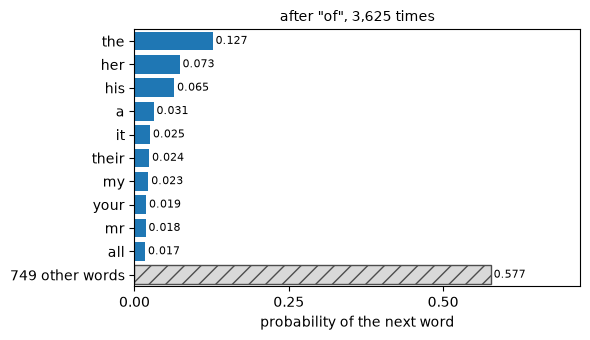

In [2]:
WORD = "of"
show_next(WORD)

### Solution

In [3]:
ctx, c = next_words(WORD, 1)
if c:
    rest = sum(x for _, x in ranked(c)[10:]) / sum(c.values())
    shown = (f"the ten likeliest, and the hatched bar the other {len(c) - 10:,} at {rest:.3f}"
             if len(c) > 10 else "all of them")
    display(Markdown(f"The likeliest word after \"{ctx[0]}\" is {likeliest(c)}. {len(c):,} "
                     f"different word(s) follow it, and the bars show {shown}. The "
                     f"{len(types) - len(c):,} word types that never follow it get probability 0."))

The likeliest word after "of" is "the", 460 of 3,625 times (probability 0.127). 759 different word(s) follow it, and the bars show the ten likeliest, and the hatched bar the other 749 at 0.577. The 5,555 word types that never follow it get probability 0.

## 2. Greedy decoding picks the likeliest word at every step

Run the cell to continue `START` by `LENGTH` words, at most fifteen, each the
word that most often follows the word before it, a tie going to the word first
in the alphabet; then try a start of your own. At which word does the
continuation begin to repeat itself, and which words does it repeat?

elizabeth was not be so much as to be so much as to be so much


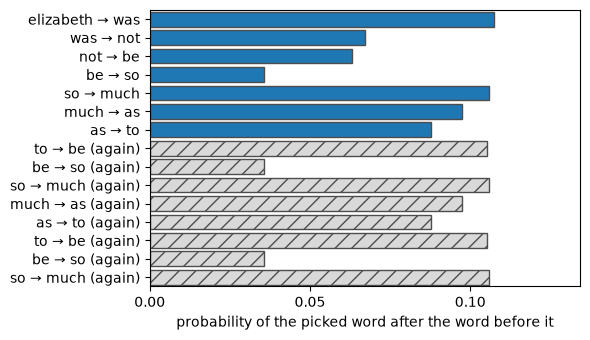

In [4]:
START = "elizabeth"
LENGTH = 15
show_greedy(START, LENGTH)

### Solution

In [5]:
out, probs, ties = greedy(START, LENGTH)
back = next((i for i in range(1, len(out)) if out[i] in out[:i]), 0)
tied = f"Word(s) where the alphabet broke a tie: {', '.join(map(str, ties)) or 'none'}."
if probs:
    display(Markdown(f"At word {back}, \"{out[back]}\", the continuation begins to repeat "
                     f"\"{' '.join(out[out.index(out[back]):back])}\" for good: one word of "
                     "context gives the same distribution after the same word, and greedy "
                     f"decoding takes the same word from it. {tied}" if back else
                     f"No word repeats among the {len(probs)} word(s) picked. {tied}"))

At word 8, "be", the continuation begins to repeat "be so much as to" for good: one word of context gives the same distribution after the same word, and greedy decoding takes the same word from it. Word(s) where the alphabet broke a tie: none.

## 3. The next word after one word of context and after two

Two words of context are counted only where the novel has both words in a row.
Run the cell, then put a context of your own into `CONTEXT`: how many times does
the novel supply each context, and which word is likeliest after each?

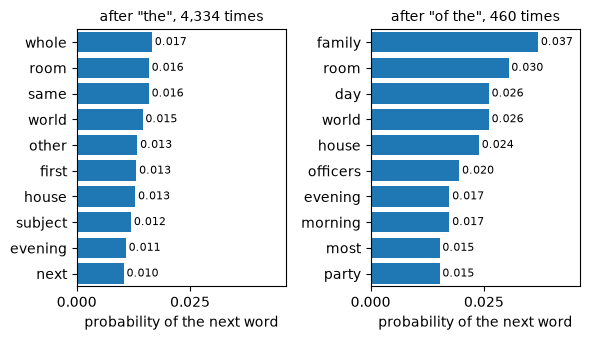

In [6]:
TWO_WORDS = True
CONTEXT = "of the"
show_next(CONTEXT, TWO_WORDS, other=False)

### Solution

In [7]:
found = [next_words(CONTEXT, n) for n in orders(TWO_WORDS)]
display(Markdown(" ".join(f"After \"{' '.join(ctx)}\" the likeliest word is {likeliest(c)}."
                          for ctx, c in found if c)))

After "the" the likeliest word is "whole", 72 of 4,334 times (probability 0.017). After "of the" the likeliest word is "family", 17 of 460 times (probability 0.037).

## Appendix. Counts from a growing share of the novel

A count model estimates the probability of a word w after a context c as a
ratio of two counts:

P(w | c) = count(c w) / count(c).

A word that never follows c in the text counted gets P(w | c) = 0, and so does
every sentence that holds c w, however ordinary the rest of it is. The
probabilities after "mr" of the five words likeliest after it in the whole
novel, counted on its first tenth, its first two tenths, and so on to all of
it:

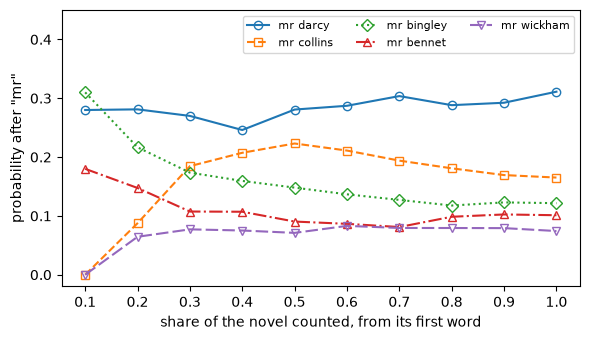

In [8]:
fractions = [k / 10 for k in range(1, 11)]
counts = [prefix_follow("mr", f) for f in fractions]
fig, ax = plt.subplots()
for (w, _), m, ls in zip(ranked(counts[-1], 5), "osD^v", ["-", "--", ":", "-.", (0, (6, 2))]):
    p = [c[w] / sum(c.values()) for c in counts]
    ax.plot(fractions, p, marker=m, linestyle=ls, markerfacecolor="none", label=f"mr {w}")
ax.set(xlabel="share of the novel counted, from its first word", xticks=fractions,
       ylabel="probability after \"mr\"", ylim=(-0.02, 0.45))
ax.legend(ncol=3, fontsize=8, loc="upper right")
plt.show()

**Exercise.** Set `FRACTION` to 0.1, then 0.5, then 1, and rerun the cell each
time. Why do fewer of the words that follow "mr" in the novel get probability 0
as the share grows, and which words still get probability 0 after "mr" when all
of the novel is counted?

In [9]:
FRACTION = 0.1

zeros = after_mr(FRACTION)

0.1: likeliest "bingley", 31 of 100 times (probability 0.310); 13 of the 25 words after "mr" at probability 0: "collins", "wickham", "darcy's", "gardiner", "collins's", "and", "wickham's", "denny", "gardiner's", "philips's", "fitzwilliam", "stone", "what's"


### Solution

In [10]:
zeros = {f: after_mr(f) for f in [0.1, 0.5, 1]}
never = len(types) - len(prefix_follow("mr", 1))
display(Markdown(
    f"A word gets probability 0 after \"mr\" until the text counted holds it after \"mr\" once: "
    f"{len(zeros[0.1])} words at a tenth, \"{zeros[0.1][0]}\" among them, {len(zeros[0.5])} at "
    f"half, {len(zeros[1])} at all of it. With all of it counted, the {never:,} word types that "
    "never follow \"mr\" in the novel still get probability 0 after it."))

0.1: likeliest "bingley", 31 of 100 times (probability 0.310); 13 of the 25 words after "mr" at probability 0: "collins", "wickham", "darcy's", "gardiner", "collins's", "and", "wickham's", "denny", "gardiner's", "philips's", "fitzwilliam", "stone", "what's"
0.5: likeliest "darcy", 146 of 520 times (probability 0.281); 2 of the 25 words after "mr" at probability 0: "stone", "what's"
1: likeliest "darcy", 243 of 781 times (probability 0.311); 0 of the 25 words after "mr" at probability 0: none


A word gets probability 0 after "mr" until the text counted holds it after "mr" once: 13 words at a tenth, "collins" among them, 2 at half, 0 at all of it. With all of it counted, the 6,289 word types that never follow "mr" in the novel still get probability 0 after it.